____
# Spatial scales


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=3
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
max_ggd = 1e-4
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Gaussian

In [6]:
#GAUSSIAN
cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key= alti_product_key,
        alti_diff_method = 'gaussian_aviso',
        alti_diff_method_param = '',
        ggd_var = 'etac',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

# Closure figs
dsg = compute_variance(DSG, compute_error='centrallimit')/U2

DSG = DSG.rename({'id_comb':'cutoff'})
DSG['cutoff'] = DSG.cutoff/1000
DSG['cutoff'] = DSG['cutoff'].assign_attrs({'long_name': 'Gaussian filter cutoff', 'units':'km'})
dsg = dsg.rename({'id_comb':'cutoff'})
dsg['cutoff'] = dsg.cutoff/1000
dsg['cutoff'] = dsg['cutoff'].assign_attrs({'long_name': 'Gaussian filter cutoff', 'units':'km'})

313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_4000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_6000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_8000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_10000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_12000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_14000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_16000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_18000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_gaussian_aviso_20000_etac__era5_rio0
313290
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_

In [5]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_aviso_{colocs_sources}_filtered.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [7]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_aviso_{colocs_sources}_calibrated.nc'))

## If already computed

In [3]:
dsgf = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'gaussian_aviso_{colocs_sources}_filtered.nc'))
dsgc = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'gaussian_aviso_{colocs_sources}_calibrated.nc'))

In [4]:
# No filter point

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'xarray_diff',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')
comb_list = [base_dic, update_dict(base_dic, {'ggd_var':'etac'})]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',['filtered', 'calibrated'])
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',['filtered', 'calibrated'])
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSH = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


# Closure figs
dsh = compute_variance(DSH, compute_error='centrallimit')/U2

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etaf__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etac__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etaf__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_xarray_diff__etac__era5_rio15
Identified SWOT and drifter outliers have been removed
2011


In [5]:
dsh['cutoff'] = xr.DataArray([0], dims='cutoff')
dsh = dsh.set_coords('cutoff')

In [6]:
dsgc = xr.concat([dsh.sel(id_comb='calibrated'), dsgc], dim='cutoff')
dsgf = xr.concat([dsh.sel(id_comb='filtered'), dsgf], dim='cutoff')

## L4

In [7]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [base_dic, 
             update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
             update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
             update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),    
]

l = ['L3-SWOT 2km', 'L4_noswot_regional', 'L4_noswot_global', 'L4_withnadirswot']

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

# Closure figs
ds4 = compute_variance(DS4, compute_error = 'centrallimit')/U2

DS4 = DS4.rename({'id_comb':'altiprod'})
DS4['altiprod'] = DS4['altiprod'].assign_attrs({'long_name': 'Altimetric products'})

ds4 = ds4.rename({'id_comb':'altiprod'})
ds4['altiprod'] = ds4['altiprod'].assign_attrs({'long_name': 'Altimetric products'})

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
12h_spectral_decomp_all_med_variational_10min_v1____L4_noswot_global_fromduacsv__fromduacsv__era5_rio15
only 'from

In [8]:
DS4.latitude.mean()

<xarray.DataArray 'latitude' ()> Size: 8B
array(40.41843757)

In [8]:
DS4['altiprod'] = ['L3-2km', 'L4-regional', 'L4-global', 'L4-SWOT-nadir']
ds4 = compute_variance(DS4)/U2

# Diagnoses

In [9]:
# Theoritical estimation from chelton 2024 (eq 3b chelton 2022)
def theoritical_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3d chelton 2022 + estimation correlation Chelton2024
    g=9.81
    return 2*g**2*(1-cor)*sigmassh**2/(cutoff**2)

def fit_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3-5 Chelton 2024
    g=9.81
    f37 = 2 * 2 * np.pi / 86164.1 * np.sin(37* np.pi / 180)
    alphauv = 13.86
    return sigmassh**2/0.4*alphauv/(cutoff**2)#*(f37**2)


from scipy.optimize import curve_fit
# Exp fit for balanced contributions
def exp_fit(cutoff, a, b):
    return a*np.exp(-cutoff/b)
cutoff = xr.DataArray(data = np.arange(0, 55, 1), 
                      dims=["cutoff"],
                      name='cutoff'
                     )
b_exp_popt, b_pcov = curve_fit(exp_fit, dsgf.cutoff, dsgf.B_ggd)
b_exp_fit = xr.DataArray(exp_fit(cutoff, *b_exp_popt), coords={'cutoff':cutoff})


In [19]:
ds4

<xarray.Dataset> Size: 2kB
Dimensions:       (altiprod: 4)
Coordinates:
  * altiprod      (altiprod) <U13 208B 'L3-2km' ... 'L4-SWOT-nadir'
Data variables: (12/66)
    ACCn          (altiprod) float64 32B 1.797 1.797 1.797 1.797
    CORn          (altiprod) float64 32B 3.357 3.357 3.357 3.357
    GGDn          (altiprod) float64 32B 1.682 0.5142 0.3816 0.587
    WDn           (altiprod) float64 32B 0.0925 0.0925 0.0925 0.0925
    Sn            (altiprod) float64 32B 1.296 1.486 1.54 1.399
    ACCe          (altiprod) float64 32B 1.727 1.727 1.727 1.727
    ...            ...
    X_acc_wd      (altiprod) float64 32B -0.1003 -0.1003 -0.1003 -0.1003
    X_cor_ggd     (altiprod) float64 32B 4.398 1.858 1.601 2.15
    X_cor_wd      (altiprod) float64 32B 1.116 1.116 1.116 1.116
    X_ggd_wd      (altiprod) float64 32B 0.05148 0.000427 -0.006397 0.0203
    D_cyclo       (altiprod) float64 32B 4.124 1.676 1.454 1.936
    D_anticyclo   (altiprod) float64 32B 10.06 7.516 7.26 7.809
Attributes:
    error_method:  no

# Gaussian
## Observed

/dev/shm/pbs.3753943.datarmor0/ipykernel_41416/632851572.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.3753943.datarmor0/ipykernel_41416/632851572.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


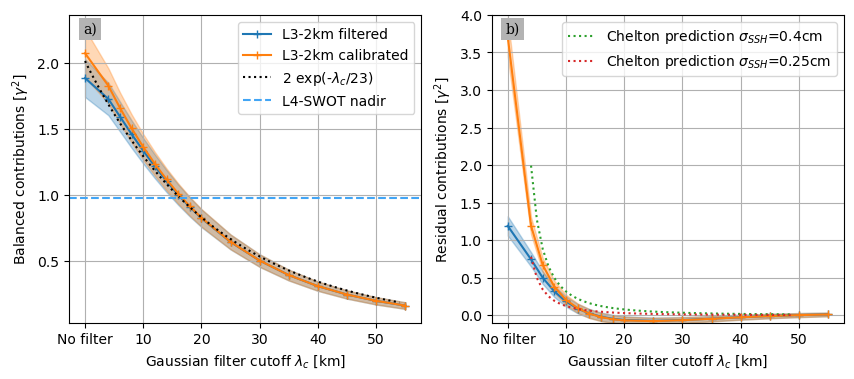

In [10]:
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize = (10, 4))

ax=axs[0]
dsgf.B_ggd.plot(ax=ax, label = 'L3-2km filtered', marker='+')
plot_error(dsgf, 'cutoff', 'B_ggd', ax=ax, suf='er__', color='tab:blue', alpha=0.3)
dsgc.B_ggd.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
plot_error(dsgc, 'cutoff', 'B_ggd', ax=ax, suf='er__', color='tab:orange', alpha=0.3)
b_exp_fit.plot(ax=ax, ls=':',color='k', label = rf'{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})')
ax.axhline(ds4.sel(altiprod='L4-SWOT-nadir').B_ggd, ls='--',  color=c0['ggd'], label = 'L4-SWOT nadir')
put_fig_letter(fig,ax, 'a')
ax.set_ylabel(r'Balanced contributions [$\gamma^2$]')


ax=axs[1]
dsgf.E_ggd.plot(ax=ax, marker='+')
plot_error(dsgf, 'cutoff', 'E_ggd', ax=ax, suf='er__', color='tab:blue', alpha=0.3)
dsgc.E_ggd.plot(ax=ax, marker='+')
plot_error(dsgc, 'cutoff', 'E_ggd', ax=ax, suf='er__', color='tab:orange', alpha=0.3)
#ax.plot(np.arange(1,50), theoritical_chelton(np.arange(1,50)*1e3, 0.5e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.5cm')
ax.plot(np.arange(4,50), theoritical_chelton(np.arange(4,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton prediction $\sigma_{SSH}$=0.4cm')
#ax.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')
ax.plot(np.arange(4,50), theoritical_chelton(np.arange(4,50)*1e3, 0.25e-2)/U2, ls=':', label ='Chelton prediction $\sigma_{SSH}$=0.25cm')


put_fig_letter(fig,ax,  'b')

ax.set_ylabel(r'Residual contributions [$\gamma^2$]')
ax.set_ylim(-0.1, 4)

for ax in axs :
    a=ax.get_xticks().tolist()
    a = [int(a_) for a_ in a]
    a[1]='No filter'
    ax.set_xticklabels(a)
    ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
    ax.grid()
    ax.legend()
    ax.set_title('')

#ins_ax_box = [0.4, 0.30, 0.58, 0.4]
#ins = axs[1].inset_axes(ins_ax_box)
#rc = (dsgf.E_ggd/(dsgf.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
#rf = (dsgc.E_ggd/(dsgc.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
#rc.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
#rf.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
#ins.set_xlim(0,14)
#ins.set_ylim(0,5)
#ins.set_title('')
#ins.grid()
#a=ins.get_xticks().tolist()
#a = [int(a_) for a_ in a]
#a[0]='No filter'
#ins.set_xticklabels(a)
#ins.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
#put_fig_letter(fig, ins, 'c')
#ins.set_ylabel(r'$R_{N/A}$')

In [23]:
((dsgc.sel(cutoff=0)-dsgc)/dsgc.sel(cutoff=0)).E_ggd

<xarray.DataArray 'E_ggd' (cutoff: 17)> Size: 136B
array([0.        , 0.67788016, 0.81862211, 0.89686682, 0.94410351,
       0.97401655, 0.99337746, 1.00582756, 1.01353415, 1.0179445 ,
       1.02052138, 1.01726409, 1.01204451, 1.00676937, 1.00233481,
       0.99898051, 0.99661704])
Coordinates:
    id_comb  <U10 40B 'calibrated'
  * cutoff   (cutoff) float64 136B 0.0 4.0 6.0 8.0 10.0 ... 40.0 45.0 50.0 55.0

In [30]:
((dsgc.sel(cutoff=0)-dsgc)/dsgc.sel(cutoff=0)).E_ggd.to_dataframe()

,id_comb,E_ggd
cutoff,,
0.0,calibrated,0.000000
4.0,calibrated,0.677880
6.0,calibrated,0.818622
8.0,calibrated,0.896867
10.0,calibrated,0.944104
12.0,calibrated,0.974017
14.0,calibrated,0.993377
16.0,calibrated,1.005828
18.0,calibrated,1.013534


In [29]:
(((dsgf.sel(cutoff=0)-dsgf)/dsgf.sel(cutoff=0)).E_ggd).to_dataframe()

,id_comb,E_ggd
cutoff,,
0.0,filtered,0.000000
4.0,filtered,0.373984
6.0,filtered,0.578186
8.0,filtered,0.732549
10.0,filtered,0.844559
12.0,filtered,0.923391
14.0,filtered,0.977698
16.0,filtered,1.014147
18.0,filtered,1.037527


In [31]:
dsgc.sel(cutoff=0)[['B_ggd', 'E_ggd', 'er__B_ggd', 'er__E_ggd']]

<xarray.Dataset> Size: 80B
Dimensions:    ()
Coordinates:
    id_comb    <U10 40B 'calibrated'
    cutoff     float64 8B 0.0
Data variables:
    B_ggd      float64 8B 2.077
    E_ggd      float64 8B 3.707
    er__B_ggd  float64 8B 0.1844
    er__E_ggd  float64 8B 0.2605
Attributes:
    error_method:  centrallimit

In [20]:
dsgf.sel(cutoff=0)[['B_ggd', 'E_ggd']]-dsgc.sel(cutoff=4)[['B_ggd', 'E_ggd']]


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    B_ggd    float64 8B 0.05828
    E_ggd    float64 8B -0.002534

In [21]:
dsgf.sel(cutoff=0)[['er__B_ggd', 'er__E_ggd']]+dsgc.sel(cutoff=4)[['er__B_ggd', 'er__E_ggd']]


<xarray.Dataset> Size: 16B
Dimensions:    ()
Data variables:
    er__B_ggd  float64 8B 0.2773
    er__E_ggd  float64 8B 0.2443

In [20]:
dsgf.sel(cutoff=0)[['B_ggd', 'E_ggd']]-dsgc.sel(cutoff=4)[['B_ggd', 'E_ggd']]


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    B_ggd    float64 8B 0.05828
    E_ggd    float64 8B -0.002534

In [14]:
dsgc.sel(cutoff=6)[['B_ggd', 'E_ggd']]

<xarray.DataArray 'E_ggd' (cutoff: 17)> Size: 136B
array([ 3.70745264,  1.19424406,  0.67244994,  0.38236138,  0.20723358,
        0.09633241,  0.02455275, -0.02160539, -0.05017721, -0.06652838,
       -0.07608205, -0.06400581, -0.04465444, -0.02509711, -0.00865621,
        0.00377971,  0.01254217])
Coordinates:
    id_comb  <U10 40B 'calibrated'
  * cutoff   (cutoff) float64 136B 0.0 4.0 6.0 8.0 10.0 ... 40.0 45.0 50.0 55.0

In [12]:
dsgc

<xarray.Dataset> Size: 18kB
Dimensions:           (cutoff: 17)
Coordinates:
    id_comb           <U10 40B 'calibrated'
  * cutoff            (cutoff) float64 136B 0.0 4.0 6.0 8.0 ... 45.0 50.0 55.0
Data variables: (12/132)
    ACCn              (cutoff) float64 136B 1.813 1.805 1.805 ... 1.805 1.805
    CORn              (cutoff) float64 136B 3.406 3.386 3.386 ... 3.386 3.386
    GGDn              (cutoff) float64 136B 3.232 1.805 1.45 ... 0.09509 0.07754
    WDn               (cutoff) float64 136B 0.08115 0.081 0.081 ... 0.081 0.081
    Sn                (cutoff) float64 136B 2.793 1.569 1.385 ... 1.945 1.979
    ACCe              (cutoff) float64 136B 1.74 1.738 1.738 ... 1.738 1.738
    ...                ...
    er__X_acc_wd      (cutoff) float64 136B 0.09007 0.08804 ... 0.08804 0.08804
    er__X_cor_ggd     (cutoff) float64 136B 0.4605 0.3233 ... 0.07046 0.06436
    er__X_cor_wd      (cutoff) float64 136B 0.2251 0.2186 ... 0.2186 0.2186
    er__X_ggd_wd      (cutoff) float64 136B 0.1111 0.06443 ... 0.01608 0.01568
    er__D_cyclo       (cutoff) float64 136B 0.3879 0.2763 ... 0.05902 0.05367
    er__D_anticyclo   (cutoff) float64 136B 0.6851 0.5744 ... 0.4507 0.4487
Attributes:
    error_method:  centrallimit

In [20]:
def plot_error(df, x, v, ax, suf = 'er__', color ="silver", alpha=1):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color=color, alpha=alpha
    )

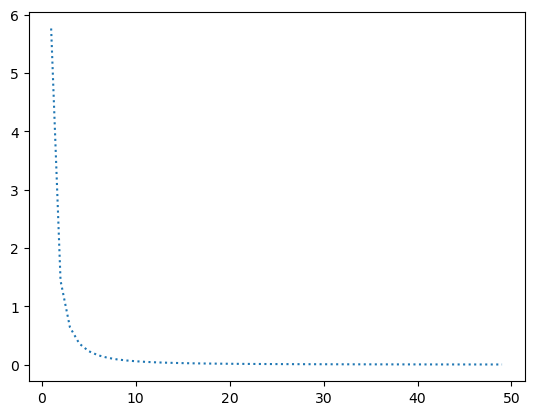

In [21]:
plt.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')


KeyError: "not all values found in index 'altiprod'. Try setting the `method` keyword argument (example: method='nearest')."

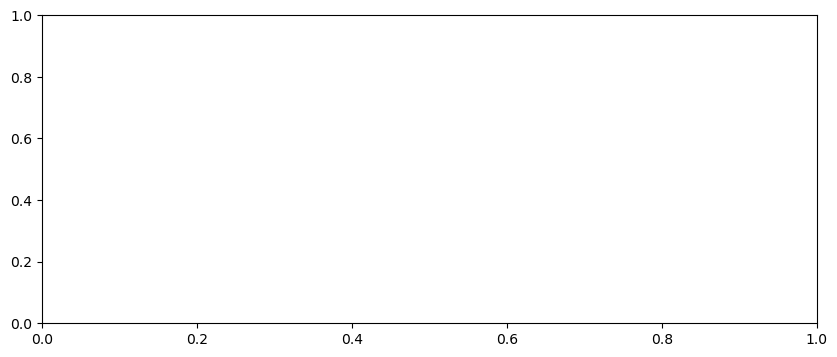

In [25]:
from matplotlib.gridspec import GridSpec

fig, ax = plt.subplots(1, 1, frameon=False, figsize = (10, 4))
rc = (dsgc.E_ggd/(dsgc.B_ggd -ds4.sel(altiprod='L4_withnadirswot').B_ggd).values)
rf = (dsgf.E_ggd/(dsgf.B_ggd -ds4.sel(altiprod='L4_withnadirswot').B_ggd).values)

rc.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
rf.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
ax.set_xlim(0,14)
ax.set_ylabel(r'Residual contribution over the difference with L4')
ax.grid()
a=ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[0]='No filter'
ax.set_xticklabels(a)
ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
ax.set_ylim(0, 6)
ax.set_title('')


In [26]:
a

[-10, 'No filter', 10, 20, 30, 40, 50, 60]

In [27]:

# Exponential fit
b_exp_fit.plot(ax=ax, ls=':', color = 'b', label = rf'{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})')
ig.plot(ax=ax, ls=':', color = 'k', label = rf'$\lambda^{-2}$ fit')
# best fit but not exponenetial
#e_fit.sel(cutoff = slice(5, 55)).plot(ax=ax, ls=':',color = 'k', label = rf'{round(e_popt[0])} exp(-$\lambda_c$/{round(e_popt[1])}) - {round(e_popt[2])}/$\lambda_c^{round(e_popt[3])}$')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker = '*', c=c0['ggd'])
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker = '*', c='grey')
#dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[3:4]:
    ax.axhline(ds4.sel(altiprod=ap).B_ggd, ls='--',  color=c0['ggd'], label = ap + ' Balanced contribution')
    #ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    #ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    #ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')

ax.set_xlim(-1, 57)

a=ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[1]='No filter'

ax.set_xticklabels(a)
ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_ylim(-0.5,4)


NameError: name 'ig' is not defined

Text(0, 0.5, '[$\\gamma^2$]')

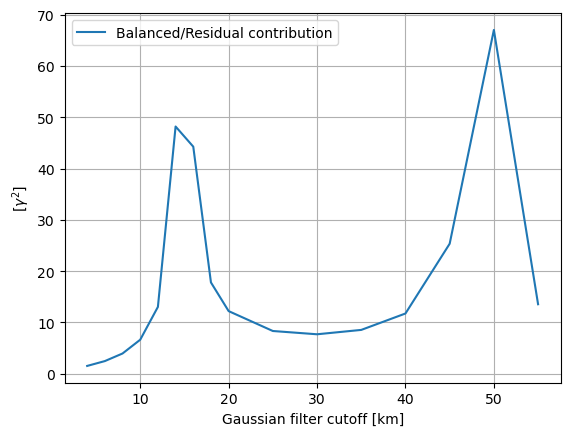

In [28]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
abs(dsg.B_ggd/dsg.E_ggd).plot(ax=ax, label = 'Balanced/Residual contribution')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Theoritical -> not the good model 

In [158]:
dsms = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', 'ms_noise_gaussian.nc'))
dsms['cutoff'] = dsms['cutoff']/1000

Text(0, 0.5, '[$\\gamma^2$]')

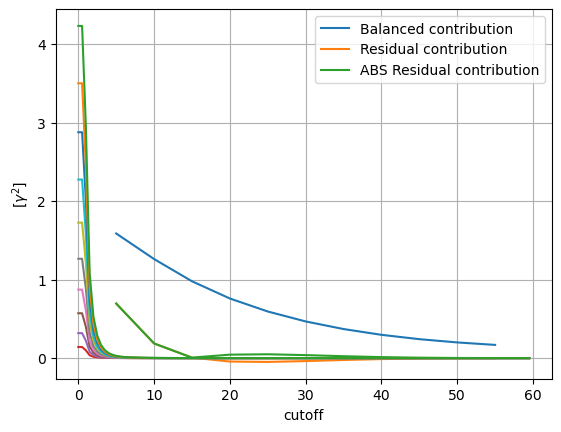

In [162]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution')
dsg.E_ggd.plot(ax=ax, label = 'Residual contribution')
abs(dsg.E_ggd).plot(ax=ax, label = 'ABS Residual contribution')
dsms.ms_noise_ggd.plot(hue='sigmassh', ax=ax)
#dsg.GGD.plot(ax=ax, label = 'MS')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km1)), ls='--', label = 'sig3km = 0.4 cm')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km2)), ls='--', label = 'sig3km = 0.25 cm')
#e_fit.plot(ls=':', label = rf'{np.round(e_popt[0])}exp(-{np.round(e_popt[1], 2)}$\lambda_c$) - {np.round(e_popt[2], 2)}/$\lambda_c$^{np.round(e_popt[3], 2)}')
#b_fit.plot(ls=':')
#b_exp_fit.plot(ls=':', label = rf'{np.round(b_exp_popt[0])}exp(-{np.round(b_exp_popt[1], 2)}$\lambda_c$)')
#g_exp_fit.plot(ls=':', label = rf'{np.round(g_exp_popt[0])}exp(-{np.round(g_exp_popt[1], 4)}*$\lambda_c$)')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

## Other quantities

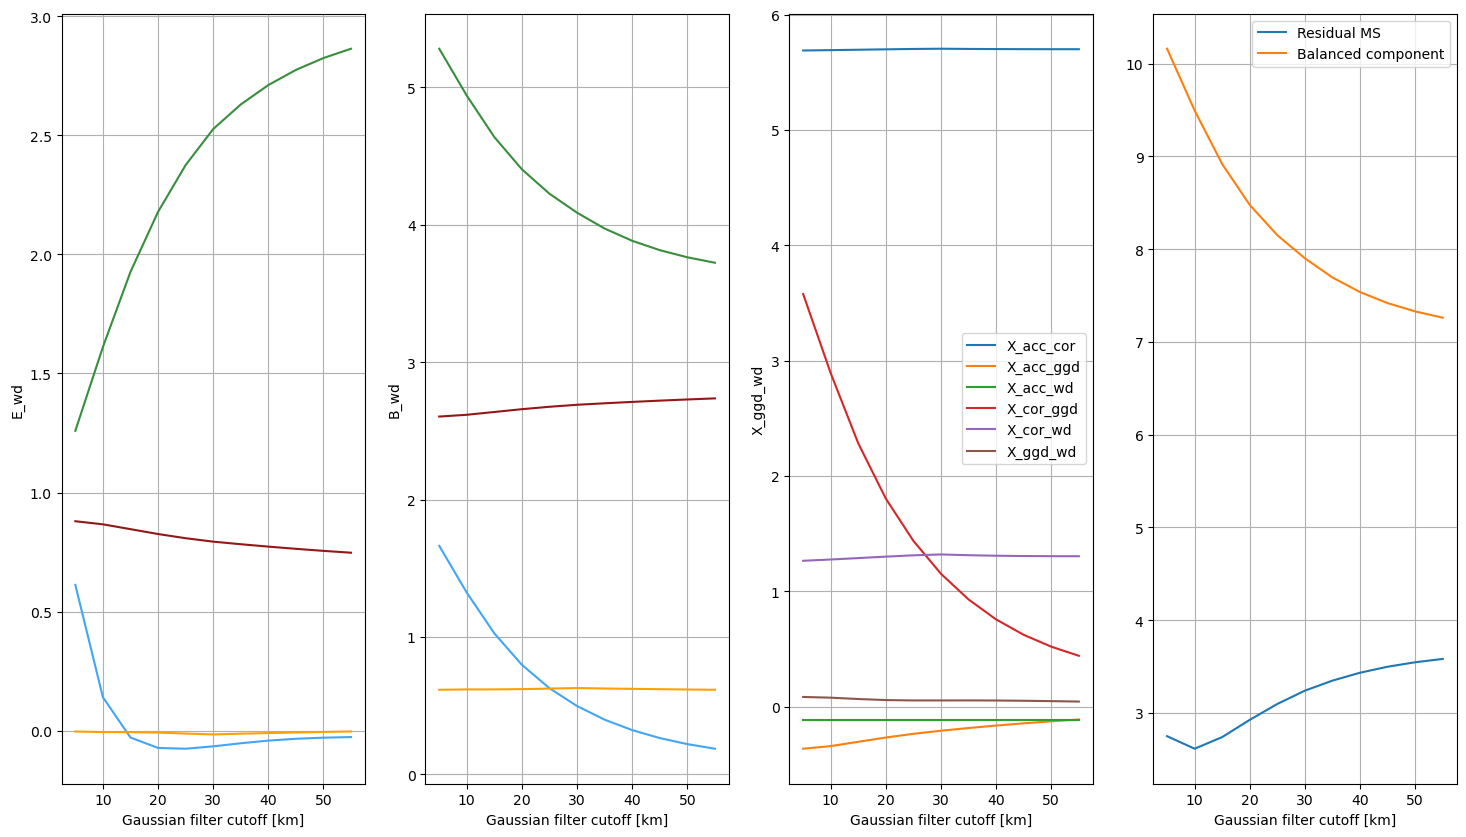

In [13]:
fig, axs = plt.subplots(1,4, figsize=(18, 10))
ax=axs[0]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['E_'+v].plot(color=c0[v], ax=ax)
ax=axs[1]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['B_'+v].plot(color=c0[v], ax=ax)
ax=axs[2]
for v in [v for v in dsg if ('X_' in v)&('ser__' not in v)]: 
    dsg[v].plot(label=v, ax=ax)
    ax.legend()

ax=axs[3]
dsg.S.plot( ax=ax, label='Residual MS') 
(sum([dsg['B_'+v] for v in ['acc', 'ggd', 'cor', 'wd']])).plot(ax=ax, label='Balanced component') 
ax.legend()

for ax in axs :
    ax.grid()

# Fitting kernel - Not working

In [5]:
#FITTING KERNEL
npts = np.arange(5, 19, 2)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fitting_kernel',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',npts)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',npts)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSF = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


DSF = DSF.rename({'id_comb':'npts'})
DSF['npts'] = DSF.npts
DSF['npts'] = DSF['npts'].assign_attrs({'long_name': 'Fitting kernel number of points', 'units':'npts'})


# Closure figs
dsf = compute_mean_square(DSF)/U2


289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio0
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio0
264246
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_9_etaf__era5_rio0
250794
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_11_etaf__era5_rio0
237840
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_13_etaf__era5_rio0
223946
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_15_etaf__era5_rio0
210192
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_17_etaf__era5_rio0
Identified SWOT and drifter outliers have been removed
289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio15
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio15
264246
12h_spectral_decomp_all_med_vari

Text(0, 0.5, '[$\\gamma^2$]')

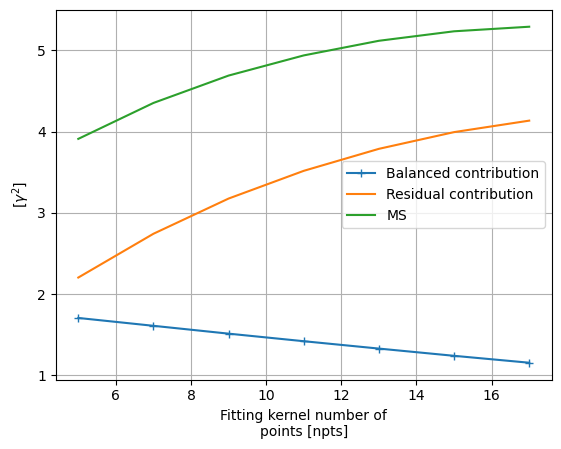

In [6]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsf.B_ggd.plot(ax=ax, label = 'Balanced contribution', marker='+')
dsf.E_ggd.plot(ax=ax, label = 'Residual contribution')
dsf.GGD.plot(ax=ax, label = 'MS')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')